In [1]:
import os
import json
from ast import literal_eval
from datetime import datetime, timedelta

import pandas as pd

import numpy as np
from IPython.display import clear_output

from python_utilities.db_connection import DbConnection


analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')

INFO [2026-06-19 15:36:56] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [24]:
start_date = "2026-05-01"
end_date = "2026-06-19"

query= f"""
SELECT la.*, tj.job_id, tj.status as textract_status, tj.s3_link 
FROM llm_attachments la LEFT JOIN textract_jobs tj ON la.attachment_id = tj.attachment_id
WHERE la.created_at >= '{start_date}' AND la.created_at <= '{end_date}'
AND la.status = 'rejected_too_long'
"""


In [25]:
data = analytics_db.sql_to_df(query)

In [26]:
egvp = data[~data['attachment_id'].str.contains("-")]

In [27]:
egvp

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,job_id,textract_status,s3_link
2,3519495,6ba656d1-8b2b-5e2a-ada9-3338261955b7,61608456,NaN,NaN,rejected_too_long,61608456_Dokumente_52426_30042026_084937_signe...,pdf,2026-05-01 09:22:55,2026-05-01 08:44:00,ocr_source_files/2026-05-01/egvp_id_359523/616...,pair-data-engineering-new,0df0a4dc09079f449f7358de7ed17c3cd40a5cae341db8...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...
4,3519729,45ff1f29-1ab0-56da-80fc-3ff54d56c88b,61609046,NaN,NaN,rejected_too_long,61609046_0_Sammel1.pdf,pdf,2026-05-01 11:13:46,2026-05-01 10:44:00,ocr_source_files/2026-05-01/egvp_id_359527/616...,pair-data-engineering-new,52dd8019502b010872a2b50b1c96a3f923b03f365def82...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...
7,3519795,38d02160-d8c8-5f77-bc14-a519b9c6464a,61609291,NaN,NaN,rejected_too_long,61609291_Dokumente_42326_30042026_143651.pdf,pdf,2026-05-01 12:12:02,2026-05-01 11:44:00,ocr_source_files/2026-05-01/egvp_id_359530/616...,pair-data-engineering-new,e81857c58d61a105e970e7ad8ff5af509ef46c18f86b78...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...
8,3519799,06ccf869-98d4-5477-ba3b-3c03ab3d73c3,61609308,NaN,NaN,rejected_too_long,61609308_Dokumente_69426_01052026_121238.pdf,pdf,2026-05-01 12:12:02,2026-05-01 11:44:00,ocr_source_files/2026-05-01/egvp_id_359534/616...,pair-data-engineering-new,106a465a72538c8d7731f011ec3d15bcb4cb348b163e74...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...
18,3519958,37ce1c0c-279b-505d-933d-20886223e6ac,61609719,NaN,NaN,rejected_too_long,61609719_DR_II_1284_26_Zustellung_erledigt.PDF,pdf,2026-05-01 14:11:58,2026-05-01 13:44:00,ocr_source_files/2026-05-01/egvp_id_359538/616...,pair-data-engineering-new,c22fe2def2e090b6dabdee01f68fd966a375077eeb585c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7714,3739764,53e156fc-f087-5aab-a9a3-83f060ac609b,69063062,NaN,NaN,rejected_too_long,69063062_Dokumente_50626_18062026_173303_signe...,pdf,2026-06-18 18:22:46,2026-06-18 17:44:00,ocr_source_files/2026-06-18/egvp_id_392267/690...,pair-data-engineering-new,8e9726dcb278efb209866f3a3d3ea11657477d12fd1a6d...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...
7715,3739768,0e3648fe-2b3c-5f1b-a271-2b73b5518b63,69063080,NaN,NaN,rejected_too_long,69063080_DR_II_579_26_An_Gl_Abdruck_VV_senden_...,pdf,2026-06-18 18:23:31,2026-06-18 17:44:00,ocr_source_files/2026-06-18/egvp_id_392270/690...,pair-data-engineering-new,5095122b664fe0c492695d344ee79635e4c0987dc70a3c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...
7716,3739778,a6211cd0-1bef-57b7-b65b-cc6b126b0a5b,69063110,NaN,NaN,rejected_too_long,69063110_VV_103526_signed.pdf,pdf,2026-06-18 18:23:31,2026-06-18 17:44:00,ocr_source_files/2026-06-18/egvp_id_392276/690...,pair-data-engineering-new,564234ce3c9d43258fb607e5b778cc7eab5f47396d9d88...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...
7717,3739785,5603795a-50ea-5fa4-8aac-fe388aff03c6,69063136,NaN,NaN,rejected_too_long,69063136_902_DR_II_349_26_04a_An_Gl_VAK_abgege...,pdf,2026-06-18 18:23:57,2026-06-18 17:44:00,ocr_source_files/2026-06-18/egvp_id_392281/690...,pair-data-engineering-new,22065ca45cad699925842e13c86cffe3228e4d9e84d89b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...


In [29]:
egvp.status.value_counts()

status
rejected_too_long    1500
Name: count, dtype: int64

In [30]:
egvp.textract_status.value_counts()

textract_status
SUCCEEDED    1500
Name: count, dtype: int64

In [33]:
egvp.columns

Index(['id', 'ticket_uuid', 'attachment_id', 'zendesk_id', 'comment_id',
       'status', 'file_name', 'file_extension', 'status_written_at',
       'created_at', 's3_key', 's3_bucket', 'job_id', 'textract_status',
       's3_link'],
      dtype='object')

In [41]:
import json

import boto3

session = boto3.Session(
    region_name="eu-central-1",
    profile_name="739275445236_DataScienceUser",
)
s3_client = session.client("s3")


def text_from_s3_link(s3_link: str) -> str:
    """Download a Textract-blocks JSON from S3 and merge LINE blocks into text."""
    bucket, key = s3_link.replace("s3://", "").split("/", 1)
    obj = s3_client.get_object(Bucket=bucket, Key=key)
    blocks = json.loads(obj["Body"].read())
    if isinstance(blocks, dict):
        blocks = blocks.get("Blocks", [])
    return "\n".join(b["Text"] for b in blocks if b.get("BlockType") == "LINE")


INFO [2026-06-19 15:52:57] - Found credentials in shared credentials file: ~/.aws/credentials


In [42]:
# s3_link points to a JSON of Textract blocks — fetch and merge LINE blocks
egvp_with_jobs = egvp[egvp["s3_link"].notna()].copy()

egvp_with_jobs["text"] = egvp_with_jobs["s3_link"].map(text_from_s3_link)
egvp_with_jobs[["attachment_id", "s3_link", "textract_status", "text"]].head()


,attachment_id,s3_link,textract_status,text
2,61608456,s3://pair-data-engineering-new/ocr_prepared_ou...,SUCCEEDED,Katharina Hahn\nHerrenstraße 11\nObergerichtsv...
4,61609046,s3://pair-data-engineering-new/ocr_prepared_ou...,SUCCEEDED,Obergerichtsvollzieherin\nAmtsgericht: Burg\nM...
7,61609291,s3://pair-data-engineering-new/ocr_prepared_ou...,SUCCEEDED,Sandra Kaiser\nKirchstraße 9 15\nObergerichtsv...
8,61609308,s3://pair-data-engineering-new/ocr_prepared_ou...,SUCCEEDED,C. Heidenreich\nHändelstraße 4\nObergerichtsvo...
18,61609719,s3://pair-data-engineering-new/ocr_prepared_ou...,SUCCEEDED,Obergerichtsvollzieherin\nLeibnizstraße 102\nB...


In [ ]:
#egvp_with_jobs.to_csv("egvp_rejected_attachments_with_textract_text.csv", index=False)

In [71]:
max_attachment_length_tokens_egvp = 1500

get_length = lambda text: len(text.strip().split()) if text else 0


get_special_length = lambda text: len(list(filter(lambda x: len(x) > 5, text.strip().split()))) if text else 0

egvp_with_jobs["text_length"] = egvp_with_jobs["text"].map(get_length)
egvp_with_jobs["text_length_special"] = egvp_with_jobs["text"].map(get_special_length)


In [72]:
test = "sa as as assa\na\na\na\na aasdasda. s \n"
print(test)

sa as as assa
a
a
a
a aasdasda. s 



In [73]:
print(test.strip().split())

['sa', 'as', 'as', 'assa', 'a', 'a', 'a', 'a', 'aasdasda.', 's']


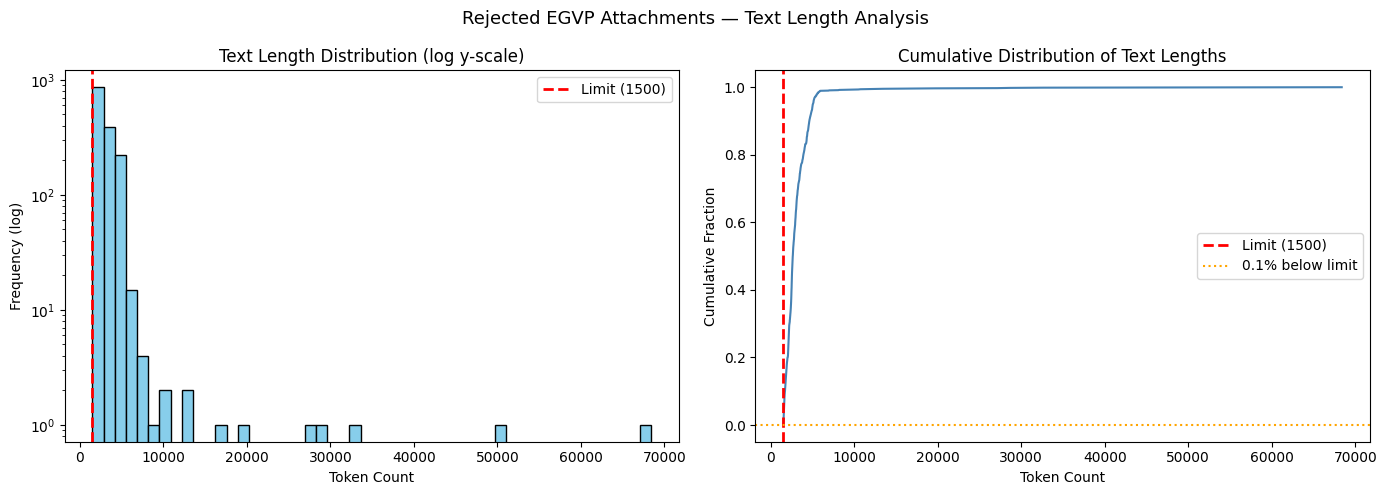

count     1500.0
mean      3086.0
std       2726.0
min       1500.0
25%       2116.0
50%       2632.0
75%       3509.0
max      68375.0
Name: text_length, dtype: float64

% above limit: 99.9%


In [74]:
import matplotlib.pyplot as plt
import numpy as np

lengths = egvp_with_jobs["text_length"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram with log y-scale to reveal long-tail shape
axes[0].hist(lengths, bins=50, color="skyblue", edgecolor="black")
axes[0].axvline(max_attachment_length_tokens_egvp, color="red", linestyle="dashed", linewidth=2, label=f"Limit ({max_attachment_length_tokens_egvp})")
axes[0].set_yscale("log")
axes[0].set_title("Text Length Distribution (log y-scale)")
axes[0].set_xlabel("Token Count")
axes[0].set_ylabel("Frequency (log)")
axes[0].legend()

# Right: CDF — shows what % of docs fall below any given length
sorted_lengths = np.sort(lengths)
cdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[1].plot(sorted_lengths, cdf, color="steelblue")
axes[1].axvline(max_attachment_length_tokens_egvp, color="red", linestyle="dashed", linewidth=2, label=f"Limit ({max_attachment_length_tokens_egvp})")
pct_below = (lengths <= max_attachment_length_tokens_egvp).mean() * 100
axes[1].axhline(pct_below / 100, color="orange", linestyle=":", linewidth=1.5, label=f"{pct_below:.1f}% below limit")
axes[1].set_title("Cumulative Distribution of Text Lengths")
axes[1].set_xlabel("Token Count")
axes[1].set_ylabel("Cumulative Fraction")
axes[1].legend()

plt.suptitle("Rejected EGVP Attachments — Text Length Analysis", fontsize=13)
plt.tight_layout()
plt.show()

print(lengths.describe().round())
print(f"\n% above limit: {(lengths > max_attachment_length_tokens_egvp).mean()*100:.1f}%")


In [75]:
egvp_with_jobs["text_length"].mean()

np.float64(3086.001333333333)

In [76]:
egvp_with_jobs["text_length"].median()

np.float64(2631.5)

In [77]:
egvp_with_jobs["text_length_special"].mean()

np.float64(1469.8446666666666)

In [78]:
egvp_with_jobs["text_length_special"].median()

np.float64(1250.5)

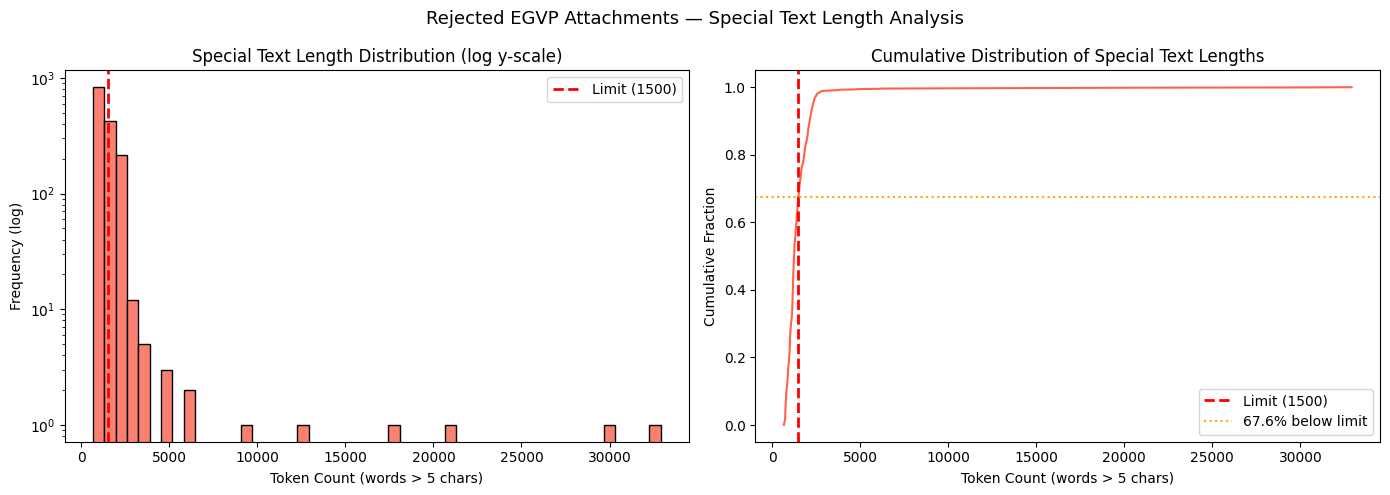

count     1500.0
mean      1470.0
std       1438.0
min        670.0
25%       1020.0
50%       1250.0
75%       1655.0
max      32907.0
Name: text_length_special, dtype: float64

% above limit: 32.4%


In [79]:
lengths_special = egvp_with_jobs["text_length_special"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lengths_special, bins=50, color="salmon", edgecolor="black")
axes[0].axvline(max_attachment_length_tokens_egvp, color="red", linestyle="dashed", linewidth=2, label=f"Limit ({max_attachment_length_tokens_egvp})")
axes[0].set_yscale("log")
axes[0].set_title("Special Text Length Distribution (log y-scale)")
axes[0].set_xlabel("Token Count (words > 5 chars)")
axes[0].set_ylabel("Frequency (log)")
axes[0].legend()

sorted_special = np.sort(lengths_special)
cdf = np.arange(1, len(sorted_special) + 1) / len(sorted_special)
axes[1].plot(sorted_special, cdf, color="tomato")
axes[1].axvline(max_attachment_length_tokens_egvp, color="red", linestyle="dashed", linewidth=2, label=f"Limit ({max_attachment_length_tokens_egvp})")
pct_below_special = (lengths_special <= max_attachment_length_tokens_egvp).mean() * 100
axes[1].axhline(pct_below_special / 100, color="orange", linestyle=":", linewidth=1.5, label=f"{pct_below_special:.1f}% below limit")
axes[1].set_title("Cumulative Distribution of Special Text Lengths")
axes[1].set_xlabel("Token Count (words > 5 chars)")
axes[1].set_ylabel("Cumulative Fraction")
axes[1].legend()

plt.suptitle("Rejected EGVP Attachments — Special Text Length Analysis", fontsize=13)
plt.tight_layout()
plt.show()

print(lengths_special.describe().round())
print(f"\n% above limit: {(lengths_special > max_attachment_length_tokens_egvp).mean()*100:.1f}%")


In [81]:
egvp_with_jobs = egvp_with_jobs[egvp_with_jobs["text_length_special"] <= max_attachment_length_tokens_egvp]

In [82]:
egvp_with_jobs

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,job_id,textract_status,s3_link,text,text_length,text_length_special
4,3519729,45ff1f29-1ab0-56da-80fc-3ff54d56c88b,61609046,NaN,NaN,rejected_too_long,61609046_0_Sammel1.pdf,pdf,2026-05-01 11:13:46,2026-05-01 10:44:00,ocr_source_files/2026-05-01/egvp_id_359527/616...,pair-data-engineering-new,52dd8019502b010872a2b50b1c96a3f923b03f365def82...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nAmtsgericht: Burg\nM...,2497,1232
7,3519795,38d02160-d8c8-5f77-bc14-a519b9c6464a,61609291,NaN,NaN,rejected_too_long,61609291_Dokumente_42326_30042026_143651.pdf,pdf,2026-05-01 12:12:02,2026-05-01 11:44:00,ocr_source_files/2026-05-01/egvp_id_359530/616...,pair-data-engineering-new,e81857c58d61a105e970e7ad8ff5af509ef46c18f86b78...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Sandra Kaiser\nKirchstraße 9 15\nObergerichtsv...,1888,942
8,3519799,06ccf869-98d4-5477-ba3b-3c03ab3d73c3,61609308,NaN,NaN,rejected_too_long,61609308_Dokumente_69426_01052026_121238.pdf,pdf,2026-05-01 12:12:02,2026-05-01 11:44:00,ocr_source_files/2026-05-01/egvp_id_359534/616...,pair-data-engineering-new,106a465a72538c8d7731f011ec3d15bcb4cb348b163e74...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,C. Heidenreich\nHändelstraße 4\nObergerichtsvo...,2447,1206
19,3519959,45f505e5-1573-5f7d-90d3-c52fb3ad14c2,61609743,NaN,NaN,rejected_too_long,61609743_4_DR_518_26_aus_Schreibmaschine.PDF,pdf,2026-05-01 14:11:58,2026-05-01 13:44:00,ocr_source_files/2026-05-01/egvp_id_359539/616...,pair-data-engineering-new,9a2d361dc59a5be00aafaa7b67038eac3e329a8447aba1...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Hauptgerichtsvollzieher\n86551 Aichach oT Ober...,2579,1235
24,3520173,5ea958bb-e4e0-50e8-bb72-7a52967a2a13,61610201,NaN,NaN,rejected_too_long,61610201_12_DR_II_359_26_0555_An_Gl_Abdruck_VV...,pdf,2026-05-01 17:11:59,2026-05-01 16:44:00,ocr_source_files/2026-05-01/egvp_id_359546/616...,pair-data-engineering-new,6c535b9f22e1fc1ad471f1f60e2bb0c5c25a5970ba4d4a...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\nPostanschrift:\nM. Fin...,3065,1446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7713,3739758,7a022228-3b8d-5f92-ad92-eed06c60852b,69063034,NaN,NaN,rejected_too_long,69063034_0_Sammel1.pdf,pdf,2026-06-18 18:23:07,2026-06-18 17:44:00,ocr_source_files/2026-06-18/egvp_id_392261/690...,pair-data-engineering-new,df0c7db8c9556c77571a0872afa62eb7386614c96ce62f...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nBüroanschrift\nNicol...,2902,1365
7714,3739764,53e156fc-f087-5aab-a9a3-83f060ac609b,69063062,NaN,NaN,rejected_too_long,69063062_Dokumente_50626_18062026_173303_signe...,pdf,2026-06-18 18:22:46,2026-06-18 17:44:00,ocr_source_files/2026-06-18/egvp_id_392267/690...,pair-data-engineering-new,8e9726dcb278efb209866f3a3d3ea11657477d12fd1a6d...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Andrea Bauer\nHolzstraße 11 4. Aufgang\n80469 ...,2322,1159
7715,3739768,0e3648fe-2b3c-5f1b-a271-2b73b5518b63,69063080,NaN,NaN,rejected_too_long,69063080_DR_II_579_26_An_Gl_Abdruck_VV_senden_...,pdf,2026-06-18 18:23:31,2026-06-18 17:44:00,ocr_source_files/2026-06-18/egvp_id_392270/690...,pair-data-engineering-new,5095122b664fe0c492695d344ee79635e4c0987dc70a3c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\nBüroanschrift\nJoachim...,3060,1424
7716,3739778,a6211cd0-1bef-57b7-b65b-cc6b126b0a5b,69063110,NaN,NaN,rejected_too_long,69063110_VV_103526_signed.pdf,pdf,2026-06-18 18:23:31,2026-06-18 17:44:00,ocr_source_files/2026-06-18/egvp_id_392276/690...,pair-data-engineering-new,564234ce3c9d43258fb607e5b778cc7eab5f47396d9d88...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Anlage zur Niederschrift d.:\nGVin Nicole Haas...,1697,818


In [83]:
sample = egvp_with_jobs.sample(100)
sample

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,job_id,textract_status,s3_link,text,text_length,text_length_special
4044,3632606,bf806ee4-5b0d-56b9-89c4-f8fa115a99ec,65447008,NaN,NaN,rejected_too_long,65447008_12052026201025VA.PDF,pdf,2026-05-27 16:23:25,2026-05-27 15:44:00,ocr_source_files/2026-05-27/egvp_id_378062/654...,pair-data-engineering-new,9cbf2f0c3a9d299f86c037beb8a539c7a274499c798ecc...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Anlage zur Niederschrift d.:\nGVin Sabrina Vin...,1612,808
3344,3611015,509add7d-e19e-5e09-99a7-850cc7032ad3,65227826,NaN,NaN,rejected_too_long,65227826_7_DR_531_26_An_Gl_VAK_bereits_geleist...,pdf,2026-05-21 15:22:36,2026-05-21 14:44:00,ocr_source_files/2026-05-21/egvp_id_374654/652...,pair-data-engineering-new,147b79f778b403e11280cd33435ad4d5ffc4fcd058be48...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nNordtangente 10 B/Rü...,2800,1335
6779,3711275,1702aa9a-af8a-54e4-8954-68cc8bd4edf6,68334609,NaN,NaN,rejected_too_long,68334609_Dokumente_34626_12062026_133902.pdf,pdf,2026-06-12 13:24:10,2026-06-12 12:44:00,ocr_source_files/2026-06-12/egvp_id_387218/683...,pair-data-engineering-new,232c2cbbdf53d6723e2b5c99ccd8489ae4979104643cc5...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Tony Westphal\nSchützenstraße 24a\nGerichtsvol...,2986,1471
3537,3616485,b6d60d51-3b21-5509-8975-502c6b24cd11,65313912,NaN,NaN,rejected_too_long,65313912_Dokumente_40026_22052026_173514-signe...,pdf,2026-05-22 17:22:59,2026-05-22 16:44:00,ocr_source_files/2026-05-22/egvp_id_376487/653...,pair-data-engineering-new,e4709445e4fa574e0281347e5c83223e4f4cded74ee6c5...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Simone Lakeberg\nCitypassage 3\nObergerichtsvo...,2605,1275
986,3548320,4fb2b275-f5dd-5831-874f-f0a34fc06cac,62302612,NaN,NaN,rejected_too_long,62302612_Dokumente_67226_07052026_132118-signe...,pdf,2026-05-07 13:37:53,2026-05-07 12:44:00,ocr_source_files/2026-05-07/egvp_id_364171/623...,pair-data-engineering-new,8af8fede15a401cc566ff8472d5fcf9192ce6d5f3db1a8...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,S. Biermann\nAdresse/Büro:\nObergerichtsvollzi...,1866,901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4506,3644757,a445f8dd-2fac-531f-ac34-f006b9b06654,65754835,NaN,NaN,rejected_too_long,65754835_DR_II_572_26_An_Gl_VAK_bereits_geleis...,pdf,2026-05-29 20:12:28,2026-05-29 19:44:00,ocr_source_files/2026-05-29/egvp_id_379280/657...,pair-data-engineering-new,a7e5e58ac933ebb3f43232c03b9e7904cfece1eb1e9f09...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\nBüro-und Postanschrift...,2604,1228
41,3521101,75f34829-b80d-574b-b302-3caa7737461e,61854680,NaN,NaN,rejected_too_long,61854680_1_Sammel1.pdf,pdf,2026-05-02 10:23:34,2026-05-02 09:44:00,ocr_source_files/2026-05-02/egvp_id_359563/618...,pair-data-engineering-new,55f9d025af05803589d004256f23b0e9dad42e06df1666...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Anlage zur Niederschrift\nvom\nGeschäftsnummer...,2109,1018
3725,3624717,076998c6-4456-598b-9168-6523d1257d23,65405990,NaN,NaN,rejected_too_long,65405990_Dokumente_44026_26052026_121818_signe...,pdf,2026-05-26 12:25:24,2026-05-26 11:44:00,ocr_source_files/2026-05-26/egvp_id_377037/654...,pair-data-engineering-new,90d85cae819599fb4bb0883b7ca7abf5f5a06837159d7c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Franziska Müller\nGerichtsvollzieherin\nbei de...,2421,1176
6118,3693759,0e40d968-8ff9-5248-b506-7983adff437a,68140746,NaN,NaN,rejected_too_long,68140746_BES_nebst_Forderungsaufstellung_08_05...,pdf,2026-06-09 17:30:59,2026-06-09 16:44:00,ocr_source_files/2026-06-09/egvp_id_384469/681...,pair-data-engineering-new,4d37655b313d77cdff06e0dbed1d8d3b861b7d4dc10dea...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Brette

In [91]:
print(egvp_with_jobs['text'].sample(10).iloc[0])

Obergerichtsvollzieher
Am Brückengut 29
Jörg Frankenberger
69427 Mudau
Bürozeiten Amtsgericht Michelstadt
Amtsgericht
Mittwochs 09:00 bis 10:00 Uhr
Michelstadt
Donnerstags 09:00 bis 10:00 Uhr
Telefon
06284 / 929180
Telefax
06284 / 929188
Jörg Frankenberger, Am Brückengut 29, 69427 Mudau
Dienstkonto
Firma
Sparkasse Neckartal-Odenwald
PAIR Finance GmbH
IBAN DE04 6745 0048 0009 2061 03
Knesebeckstraße 62-63
BIC SOLADES1MOS
10623 Berlin
Mein Zeichen
Ihr Zeichen
DR II 676/26
157475248090
Mudau, 05.05.2026
Bitte immer angeben!
Zwangsvollstreckungssache
Firma Liquandum Capital GmbH, Knesebeckstraße 62-63, 10719 Berlin
vertr. d.
Firma PAIR Finance GmbH, Knesebeckstraße 62-63, 10623 Berlin, Tel. 030/340 602 950, Fax 030 /
340 602 951, E-Mail aftercourt@pairfinance.de
gegen
Frau Zennet Sali, Pestalozzistraße 66, 64739 Höchst
Sehr geehrte Damen und Herren,
in oben genannter Zwangsvollstreckungssache haben Sie die Abnahme der Vermögensauskunft beantragt.
Ich habe nunmehr festgestellt, dass die Sch

In [85]:
import sys
sys.path.append("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation")

from utils.prod_utils import download_pdf_by_document_s3_info

DOWNLOAD_DIR = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp"
SAMPLE_SIZE = 100

sample = egvp_with_jobs[["attachment_id", "s3_key", "s3_bucket"]].dropna(subset=["s3_key", "s3_bucket"]).sample(n=SAMPLE_SIZE, random_state=42)

failed = []
for row in sample.itertuples():
    try:
        download_pdf_by_document_s3_info(
            s3=s3_client,
            document_s3_bucket=row.s3_bucket,
            document_s3_key=row.s3_key,
            download_dir=DOWNLOAD_DIR,
            file_name=str(row.attachment_id),
        )
    except Exception as e:
        print(f"❌ Failed for {row.attachment_id}: {e}")
        failed.append(row.attachment_id)

print(f"\nDone. {SAMPLE_SIZE - len(failed)}/{SAMPLE_SIZE} downloaded. {len(failed)} failed.")


✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/67499015.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/65291367.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/62536430.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/65445407.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/68339029.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/65308690.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/68249219.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/62349689.pdf
✅ PDF downloaded successfully: /Users/me